In [ ]:
!pip install labelme

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.5/985.5 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 19.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import numpy as np
from PIL import Image
from labelme import utils

# Paths
json_folder = '/content/drive/MyDrive/indian_dataset/'
mask_folder = '/content/drive/MyDrive/indian_dataset/masks/'

os.makedirs(mask_folder, exist_ok=True)

# Define label mapping
label_name_to_value = {
    "background": 0,
    "building": 1
}

# Loop over all JSON files
for file in os.listdir(json_folder):
    if file.endswith('.json'):
        json_path = os.path.join(json_folder, file)
        print(f"Processing {file}...")

        # Load JSON
        with open(json_path, 'r') as f:
            data = json.load(f)

        # Convert shapes to mask using label_name_to_value
        mask, _ = utils.shapes_to_label(
            img_shape=(data['imageHeight'], data['imageWidth']),
            shapes=data['shapes'],
            label_name_to_value=label_name_to_value
        )

        # Convert mask to binary (0=background, 255=building)
        mask = (mask > 0).astype(np.uint8) * 255

        # Save mask
        mask_path = os.path.join(mask_folder, file.replace('.json','.png'))
        Image.fromarray(mask).save(mask_path)
        print(f"Saved mask: {mask_path}")

Processing image10.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image10.png
Processing image9.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image9.png
Processing image8.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image8.png
Processing image7.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image7.png
Processing image6.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image6.png
Processing image5.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image5.png
Processing image4.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image4.png
Processing image3.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image3.png
Processing image2.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image2.png
Processing image1.json...
Saved mask: /content/drive/MyDrive/indian_dataset/masks/image1.png


In [ ]:
import os
import shutil
import random

dataset_path = '/content/drive/MyDrive/indian_dataset/'

# Paths
images_path = dataset_path  # your 10 JSON images are here, we will only use the PNG images for training
all_images = [f for f in os.listdir(images_path) if f.endswith('.png')]

# Shuffle and split
random.shuffle(all_images)
train_imgs = all_images[:8]
val_imgs = all_images[8:]

# Create folders
train_image_folder = os.path.join(dataset_path, 'images_train')
train_mask_folder = os.path.join(dataset_path, 'masks_train')
val_image_folder = os.path.join(dataset_path, 'images_val')
val_mask_folder = os.path.join(dataset_path, 'masks_val')

for folder in [train_image_folder, train_mask_folder, val_image_folder, val_mask_folder]:
    os.makedirs(folder, exist_ok=True)

# Move/copy images and masks
for img in train_imgs:
    shutil.copy(os.path.join(dataset_path, img), os.path.join(train_image_folder, img))
    shutil.copy(os.path.join(dataset_path, 'masks', img), os.path.join(train_mask_folder, img))

for img in val_imgs:
    shutil.copy(os.path.join(dataset_path, img), os.path.join(val_image_folder, img))
    shutil.copy(os.path.join(dataset_path, 'masks', img), os.path.join(val_mask_folder, img))

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np
import os

class RooftopDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transforms=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = (np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0)
        mask = (np.array(Image.open(mask_path).convert("L"), dtype=np.float32) / 255.0)
        mask = (mask > 0.5).astype(np.float32)

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # If no transforms, manually convert numpy arrays to tensors and permute image dimensions
            image = torch.tensor(image.transpose(2, 0, 1), dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.float32)

        # Ensure mask has a channel dimension (1, H, W)
        mask = mask.unsqueeze(0)
        return image, mask

# Augmentations
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Resize(height=512, width=512), # Added to ensure consistent image sizes
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=512, width=512), # Added to ensure consistent image sizes
    ToTensorV2()
])

# Create datasets
train_dataset = RooftopDataset(train_image_folder, train_mask_folder, transforms=train_transform)
val_dataset = RooftopDataset(val_image_folder, val_mask_folder, transforms=val_transform)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

In [ ]:
!pip install segmentation_models_pytorch
import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)
model.load_state_dict(torch.load('/content/drive/MyDrive/building_unet_base.pth', map_location=device))
model.to(device)
model.float() # Convert model parameters to float32

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = smp.losses.DiceLoss(mode='binary')
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def dice_score(pred, target, smooth=1e-6):
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return (2*intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

In [ ]:
num_epochs = 5  # small dataset, fewer epochs
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = torch.sigmoid(model(imgs))
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_dice, val_iou = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = torch.sigmoid(model(imgs))
            preds = (outputs > 0.5).float()
            for p, t in zip(preds, masks):
                val_dice += dice_score(p, t).item()
                val_iou += iou_score(p, t).item()
    val_dice /= len(val_dataset)
    val_iou /= len(val_dataset)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f}")

# Save updated model
torch.save(model.state_dict(), '/content/drive/MyDrive/building_unet_india_finetuned.pth')

Epoch 1/5 | Train Loss: 0.6378 | Val Dice: 0.0000 | Val IoU: 0.0000
Epoch 2/5 | Train Loss: 0.6363 | Val Dice: 0.0000 | Val IoU: 0.0000
Epoch 3/5 | Train Loss: 0.6389 | Val Dice: 0.0000 | Val IoU: 0.0000
Epoch 4/5 | Train Loss: 0.6380 | Val Dice: 0.0000 | Val IoU: 0.0000
Epoch 5/5 | Train Loss: 0.6379 | Val Dice: 0.0000 | Val IoU: 0.0000


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/building_unet_india_finetuned.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

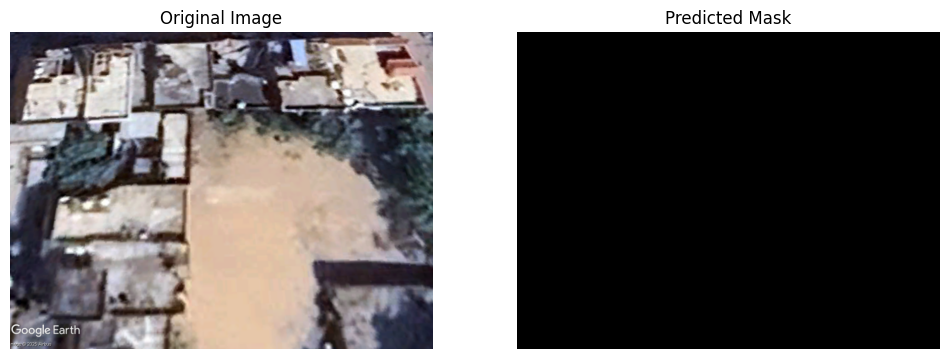

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch

# Load image
img_path = '/content/drive/MyDrive/indian_dataset/images_val/image1.png'
image = Image.open(img_path).convert("RGB")
orig_size = image.size  # save original size
image_resized = image.resize((256, 256))  # match training size

# Convert to float32 tensor
image_np = np.array(image_resized, dtype=np.float32) / 255.0
input_tensor = torch.tensor(image_np.transpose(2,0,1), dtype=torch.float32).unsqueeze(0).to(device)

# Predict
model.eval()
with torch.no_grad():
    output = torch.sigmoid(model(input_tensor))
pred_mask = (output[0,0].cpu().numpy() > 0.5).astype(np.uint8) * 255

# Resize mask back to original size
pred_mask_image = Image.fromarray(pred_mask).resize(orig_size)

# Display original image and predicted mask
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(pred_mask_image, cmap='gray')
plt.axis('off')

plt.show()